# Basic Task: Q-Learning

In [6]:
import numpy as np
import pandas as pd
import random

### Create the grid-based environment and the fundamental functions

In [ ]:
class GridCarEnv():
    def __init__(self, dims=(6,6), max_steps=30):
        self.dims = dims # (row, col)
        self.rewards = {
            'r_goal': 100, 
            'step': -1, 
            'hit_pitfall': -5,
            'hit_obstacle': -10,
            'bump_wall': -20}
        self.max_steps = max_steps
        self.start = (dims[0]-1, 0) # bottom left
        self.end = (0, dims[1]-1) # upper right
        self.positions = {'pitfalls': [(1,3),(4,1),(3,5)], 'obstacles': [(1,2),(1,4),(3,2), (4,3)]}
        self.pos = self.start
        self.reward_score = 0
        self.current_step = 0
        self.actions = { # 4 actions: 0=Up, 1=Down, 2=Left, 3=Right
            0: (-1,  0),
            1: ( 1,  0),
            2: ( 0, -1),
            3: ( 0,  1),
        }
    
    def reset(self): # in each episode, the 
        self.pos = self.start
        self.current_step = 0
        self.reward_score = 0
        return self.pos


    def step(self, move):

        reward = self.rewards['step']
        done = False
        self.current_step += 1
        if self.current_step == self.max_steps:
            done = True
            return self.pos, reward, done

        if move == 0:
            new_pos = (self.pos[0] + self.actions[0][0], self.pos[1]+ self.actions[0][1])
            if new_pos[0] == -1:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos #change position only if it is not out of bounds
        elif move == 1:
            new_pos = (self.pos[0] + self.actions[1][0], self.pos[1]+ self.actions[1][1])
            if new_pos[0] == self.dims[0]:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        elif move == 2:
            new_pos = (self.pos[0] + self.actions[2][0], self.pos[1]+ self.actions[2][1])
            if new_pos[1] == -1:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        elif move == 3:
            new_pos = (self.pos[0] + self.actions[3][0], self.pos[1]+ self.actions[3][1])
            if new_pos[1] == self.dims[1]:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        

        if self.pos in self.positions['pitfalls']:
            self.reward_score = self.reward_score + self.rewards['hit_pitfall']
            reward += self.rewards['hit_pitfall'] 
        elif self.pos == self.end:
            reward += self.rewards['r_goal']
            done = True



        return self.pos, reward, done
    

def initialize_q_table(n_states,n_actions): #initialize with zeros for q values
    q_table = np.zeros((n_states, n_actions))
    return q_table
def update_q_table(Q, alpha,r, gamma, a, s_old, s, dims):  #update using Bellman equation
    s = s[0] * dims[1] + s[1] # is a tuple (e.g (2,3)) and needs to be indexed as an integer
    Q[s_old,a] = Q[s_old,a] + alpha * ( r + gamma * np.max(Q[s,:]) - Q[s_old,a])

    return Q


### Train loop

In [1]:
def train(alpha, gamma, epsilon_decay, episodes):
    reward_list = []
    epsilon = 1 # starts with full exploration
    epsilon_min = 0.01 #always explore a little
    Q = initialize_q_table(n_states, n_actions)
    success_list = [] # how many episodes reach the end position

    for i in range(episodes): # Training loop
        pos = env.reset()
        total_reward = 0
        done = False
        
        while done is not True:
            s_old = env.pos
            s_old = s_old[0] * env.dims[1] + s_old[1] # is a tuple (e.g (2,3)) and needs to be indexed as an integer

            # e-greedy policy
            if np.random.random() < epsilon:
                action = np.random.choice(len(env.actions)) #choose a random action
            else:
                action = np.argmax(Q[s_old, :])

            pos, reward, done = env.step(action)
            total_reward += reward

            Q = update_q_table(Q, alpha, reward, gamma, action, s_old, pos, env.dims)

        epsilon = max(epsilon_min, epsilon * epsilon_decay) # apply epsilon decay 
        reward_list.append(total_reward)
        success = (env.pos == env.end)
        success_list.append(success)
    #print(Q)
    success_rate = sum(success_list) / len(success_list) * 100

    return reward_list, success_rate


### Plot performance

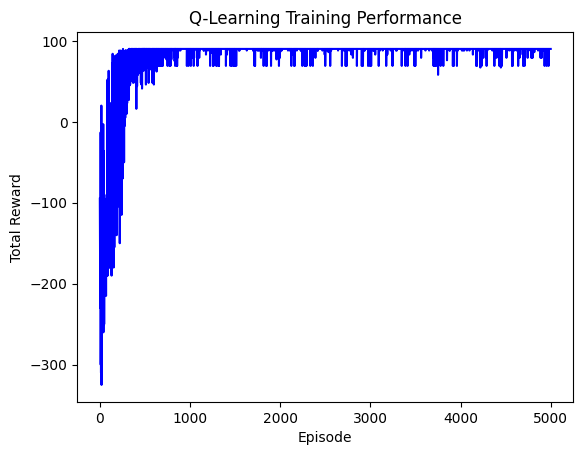

In [41]:
import matplotlib.pyplot as plt

plt.plot(reward_list, color='blue')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Training Performance')
plt.show()

### Tune hyperparameters with different values

In [32]:
alphas = [0.1, 0.3, 0.9]
gammas = [0.5, 0.9, 0.99]
epsilon_decay = [0.99, 0.995, 0.999]
episodes = 5000

def train_loop(alphas, gammas, epsilon_decay, episodes):

    results = {}
    for alpha in alphas:
        for gamma in gammas:
            for eps in epsilon_decay:
                reward_list, success_rate = train(alpha, gamma, eps, episodes)
                results[(alpha, gamma, eps)] = (reward_list, success_rate)
                print(f"alpha={alpha}, gamma={gamma}, epsilon={eps} | success rate={success_rate:.2f}% | avg reward={np.mean(reward_list):.2f}")
    return results


In [39]:
env = GridCarEnv()
n_states = env.dims[0] * env.dims[1] # 6*6 = 36 keeping the number of states at 36 for simplicity
n_actions = len(env.actions)  # 4   
#results = train_loop(alphas, gammas, epsilon_decay, episodes) 
reward_list, success_rate = train(0.1, 0.1, 0.995, 5000)

In [42]:
print(success_rate)

96.56


### Q-learning by using two policies: e-greedy and softmax

In [2]:
class GridCarEnv():
    def __init__(self, dims=(6,6), max_steps=200):
        self.dims = dims # (row, col)
        self.rewards = {
            'r_goal': 100, 
            'step': -1, 
            'hit_pitfall': -5,
            'hit_obstacle': -10,
            'bump_wall': -20}
        self.max_steps = max_steps
        self.start = (dims[0]-1, 0) # bottom left
        self.end = (0, dims[1]-1) # upper right
        self.positions = {'pitfalls': [(1,3),(4,1),(3,5)], 'obstacles': [(1,2),(1,4),(3,2), (4,3)]}
        self.pos = self.start
        self.reward_score = 0
        self.current_step = 0
        self.actions = { # 4 actions: 0=Up, 1=Down, 2=Left, 3=Right
            0: (-1,  0),
            1: ( 1,  0),
            2: ( 0, -1),
            3: ( 0,  1),
        }
    
    def reset(self):
        self.pos = self.start
        self.current_step = 0
        self.reward_score = 0
        return self.pos

    def step(self, move):

        reward = self.rewards['step']
        done = False
        self.current_step += 1
        if self.current_step == self.max_steps:
            done = True
            return self.pos, reward, done

        if move == 0:
            new_pos = (self.pos[0] + self.actions[0][0], self.pos[1]+ self.actions[0][1])
            if new_pos[0] == -1:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos #change position only if it is not out of bounds
        elif move == 1:
            new_pos = (self.pos[0] + self.actions[1][0], self.pos[1]+ self.actions[1][1])
            if new_pos[0] == self.dims[0]:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        elif move == 2:
            new_pos = (self.pos[0] + self.actions[2][0], self.pos[1]+ self.actions[2][1])
            if new_pos[1] == -1:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        elif move == 3:
            new_pos = (self.pos[0] + self.actions[3][0], self.pos[1]+ self.actions[3][1])
            if new_pos[1] == self.dims[1]:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        

        if self.pos in self.positions['pitfalls']:
            self.reward_score = self.reward_score + self.rewards['hit_pitfall']
            reward += self.rewards['hit_pitfall'] 
        elif self.pos == self.end:
            reward += self.rewards['r_goal']
            done = True

        return self.pos, reward, done
    

def initialize_q_table(n_states, n_actions):
    return np.zeros((n_states, n_actions))


def state_to_index(state, dims):
    return state[0] * dims[1] + state[1]


def update_q_table(Q, alpha, reward, gamma, action, s_old, s, dims):
    s_old_index = state_to_index(s_old, dims)
    s_index = state_to_index(s, dims)

    Q[s_old_index, action] = Q[s_old_index, action] + alpha * (
        reward + gamma * np.max(Q[s_index, :]) - Q[s_old_index, action]
    )
    return Q

def epsilon_greedy(Q, state, epsilon, dims):
    state_index = state_to_index(state, dims)

    if np.random.random() < epsilon:
        return np.random.choice(Q.shape[1])

    return np.argmax(Q[state_index, :])

def softmax(Q, state, temperature, dims):
    state_index = state[0] * dims[1] + state[1]
    q_values = Q[state_index, :]

    temperature = max(temperature, 1e-8)

    shifted_q_values = q_values - np.max(q_values)
    exp_values = np.exp(shifted_q_values / temperature)
    probabilities = exp_values / np.sum(exp_values)

    action = np.random.choice(len(q_values), p=probabilities)

    return action

In [3]:
def train(alpha, gamma, decay, episodes, policy="epsilon_greedy", max_steps=30):
    env = GridCarEnv(max_steps=max_steps)

    n_states = env.dims[0] * env.dims[1]
    n_actions = len(env.actions)

    Q = initialize_q_table(n_states, n_actions)

    epsilon = 1.0
    epsilon_min = 0.01

    temperature = 1.0
    temperature_min = 0.1

    reward_list = []
    step_list = []
    success_count = 0

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0

        for step_count in range(env.max_steps):
            s_old = state

            if policy == "epsilon_greedy":
                action = epsilon_greedy(Q, s_old, epsilon, env.dims)

            elif policy == "softmax":
                action = softmax(Q, s_old, temperature, env.dims)

            else:
                raise ValueError("policy must be 'epsilon_greedy' or 'softmax'")

            pos, reward, done = env.step(action)

            Q = update_q_table(
    Q,
    alpha,
    reward,
    gamma,
    action,
    s_old,
    pos,
    env.dims
)

            state = pos
            total_reward += reward

            if done:
                break

        if state == env.end:
            success_count += 1

        if policy == "epsilon_greedy":
            epsilon = max(epsilon_min, epsilon * decay)

        elif policy == "softmax":
            temperature = max(temperature_min, temperature * decay)

        reward_list.append(total_reward)
        step_list.append(step_count + 1)

    success_rate = (success_count / episodes) * 100

    return Q, reward_list, step_list, success_rate

In [4]:
def experiments(alphas, gammas, decay_values, policies, episodes=5000, max_steps=30):
    results = {}
    rows = []

    for policy in policies:
        for alpha in alphas:
            for gamma in gammas:
                for decay in decay_values:

                    Q, reward_list, step_list, success_rate = train(
                        alpha=alpha,
                        gamma=gamma,
                        decay=decay,
                        episodes=episodes,
                        policy=policy,
                        max_steps=max_steps
                    )

                    avg_reward = np.mean(reward_list)
                    avg_final_500_reward = np.mean(reward_list[-500:])
                    avg_steps = np.mean(step_list)
                    avg_final_500_steps = np.mean(step_list[-500:])

                    key = (policy, alpha, gamma, decay)

                    results[key] = {
                        "Q": Q,
                        "reward_list": reward_list,
                        "step_list": step_list,
                        "success_rate": success_rate,
                        "avg_reward": avg_reward,
                        "avg_final_500_reward": avg_final_500_reward,
                        "avg_steps": avg_steps,
                        "avg_final_500_steps": avg_final_500_steps
                    }

                    rows.append({
                        "policy": policy,
                        "alpha": alpha,
                        "gamma": gamma,
                        "decay": decay,
                        "success_rate": success_rate,
                        "avg_reward": avg_reward,
                        "avg_final_500_reward": avg_final_500_reward,
                        "avg_steps": avg_steps,
                        "avg_final_500_steps": avg_final_500_steps,
                        "key": key
                    })

                    print(
                        f"{policy} | alpha={alpha}, gamma={gamma}, decay={decay} | "
                        f"success={success_rate:.2f}% | avg reward={avg_reward:.2f} | "
                        f"avg steps={avg_steps:.2f}"
                    )

    summary_df = pd.DataFrame(rows)

    return results, summary_df

In [7]:
alphas = [0.1, 0.3, 0.9]
gammas = [0.1, 0.3, 0.9]
decay_values = [0.9, 0.99, 0.999, 0.9999]
policies = ["epsilon_greedy", "softmax"]

episodes = 5000
max_steps = 30

results, summary_df = experiments(
    alphas=alphas,
    gammas=gammas,
    decay_values=decay_values,
    policies=policies,
    episodes=episodes,
    max_steps=max_steps
)

epsilon_greedy | alpha=0.1, gamma=0.1, decay=0.9 | success=97.90% | avg reward=86.27 | avg steps=10.75
epsilon_greedy | alpha=0.1, gamma=0.1, decay=0.99 | success=97.10% | avg reward=82.89 | avg steps=10.91
epsilon_greedy | alpha=0.1, gamma=0.1, decay=0.999 | success=92.28% | avg reward=56.74 | avg steps=13.50
epsilon_greedy | alpha=0.1, gamma=0.1, decay=0.9999 | success=32.74% | avg reward=-109.63 | avg steps=27.22
epsilon_greedy | alpha=0.1, gamma=0.3, decay=0.9 | success=99.00% | avg reward=87.77 | avg steps=10.42
epsilon_greedy | alpha=0.1, gamma=0.3, decay=0.99 | success=98.42% | avg reward=84.85 | avg steps=10.61
epsilon_greedy | alpha=0.1, gamma=0.3, decay=0.999 | success=91.94% | avg reward=56.50 | avg steps=13.56
epsilon_greedy | alpha=0.1, gamma=0.3, decay=0.9999 | success=32.96% | avg reward=-108.94 | avg steps=27.19
epsilon_greedy | alpha=0.1, gamma=0.9, decay=0.9 | success=99.58% | avg reward=88.31 | avg steps=10.27
epsilon_greedy | alpha=0.1, gamma=0.9, decay=0.99 | succe

In [8]:
import matplotlib.pyplot as plt

top5_each_policy = (
    summary_df
    .sort_values(["policy", "avg_reward"], ascending=[True, False])
    .groupby("policy")
    .head(5)
)

worst5_each_policy = (
    summary_df
    .sort_values(["policy", "avg_reward"], ascending=[True, True])
    .groupby("policy")
    .head(5)
)

top5_each_policy[
    [
        "policy",
        "alpha",
        "gamma",
        "decay",
        "success_rate",
        "avg_reward",
        "avg_final_500_reward",
        "avg_steps",
        "avg_final_500_steps"
    ]
]

,policy,alpha,gamma,decay,success_rate,avg_reward,avg_final_500_reward,avg_steps,avg_final_500_steps
32,epsilon_greedy,0.9,0.9,0.9000,99.72,88.6842,89.306,10.1858,10.114
24,epsilon_greedy,0.9,0.1,0.9000,99.74,88.6026,89.338,10.1804,10.072
28,epsilon_greedy,0.9,0.3,0.9000,99.74,88.5650,89.016,10.1930,10.134
20,epsilon_greedy,0.3,0.9,0.9000,99.66,88.5298,89.258,10.2232,10.152
16,epsilon_greedy,0.3,0.3,0.9000,99.58,88.5220,89.554,10.2330,10.106
68,softmax,0.9,0.9,0.9000,99.80,89.6250,90.000,10.0580,10.000
70,softmax,0.9,0.9,0.9990,99.76,89.5560,90.000,10.0740,10.000
71,softmax,0.9,0.9,0.9999,99.74,89.5452,90.000,10.0798,10.000
69,softmax,0.9,0.9,0.9900,99.74,89.5396,90.000,10.0784,10.000
56,softmax,0.3,0.9,0.9000,99.64,89.4102,90.000,10.0968,10.000


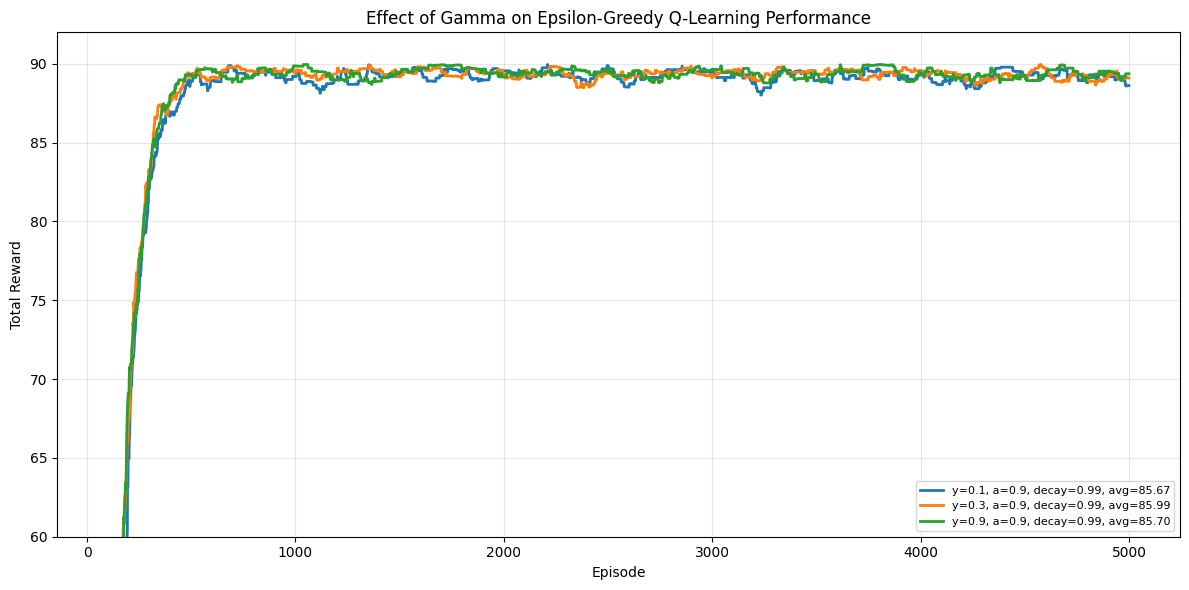

In [9]:
policy = "epsilon_greedy"
fixed_alpha = 0.9
fixed_decay = 0.99
window = 100

gamma_effect_df = summary_df[
    (summary_df["policy"] == policy) &
    (summary_df["alpha"] == fixed_alpha) &
    (summary_df["decay"] == fixed_decay)
].sort_values("gamma")

plt.figure(figsize=(12, 6))

for row in gamma_effect_df.itertuples():
    reward_list = results[row.key]["reward_list"]
    moving_average = pd.Series(reward_list).rolling(window=window).mean()
    episodes_range = range(1, len(reward_list) + 1)

    label = f"y={row.gamma}, a={row.alpha}, decay={row.decay}, avg={row.avg_reward:.2f}"
    plt.plot(episodes_range, moving_average, linewidth=2, label=label)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Effect of Gamma on Epsilon-Greedy Q-Learning Performance")
plt.legend(loc="best", fontsize=8, frameon=True)
plt.grid(True, alpha=0.3)
plt.ylim(60, 92)
plt.tight_layout()
plt.savefig("gamma_effect_reward_curve.png", dpi=300, bbox_inches="tight")
plt.show()

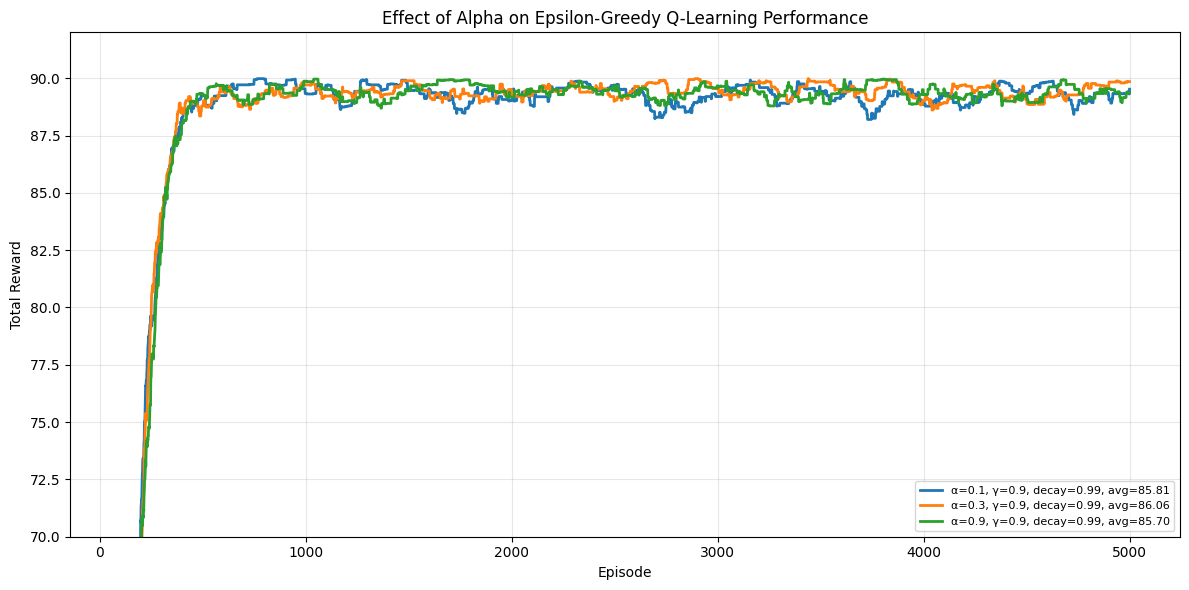

In [10]:
policy = "epsilon_greedy"
fixed_gamma = 0.9
fixed_decay = 0.99
window = 100

alpha_effect_df = summary_df[
    (summary_df["policy"] == policy) &
    (summary_df["gamma"] == fixed_gamma) &
    (summary_df["decay"] == fixed_decay)
].sort_values("alpha")

plt.figure(figsize=(12, 6))

for row in alpha_effect_df.itertuples():
    reward_list = results[row.key]["reward_list"]
    moving_average = pd.Series(reward_list).rolling(window=window).mean()
    episodes_range = range(1, len(reward_list) + 1)

    label = f"α={row.alpha}, γ={row.gamma}, decay={row.decay}, avg={row.avg_reward:.2f}"
    plt.plot(episodes_range, moving_average, linewidth=2, label=label)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Effect of Alpha on Epsilon-Greedy Q-Learning Performance")
plt.legend(loc="best", fontsize=8, frameon=True)
plt.grid(True, alpha=0.3)
plt.ylim(70, 92)
plt.tight_layout()
plt.savefig("alpha_effect_reward_curve.png", dpi=300, bbox_inches="tight")
plt.show()

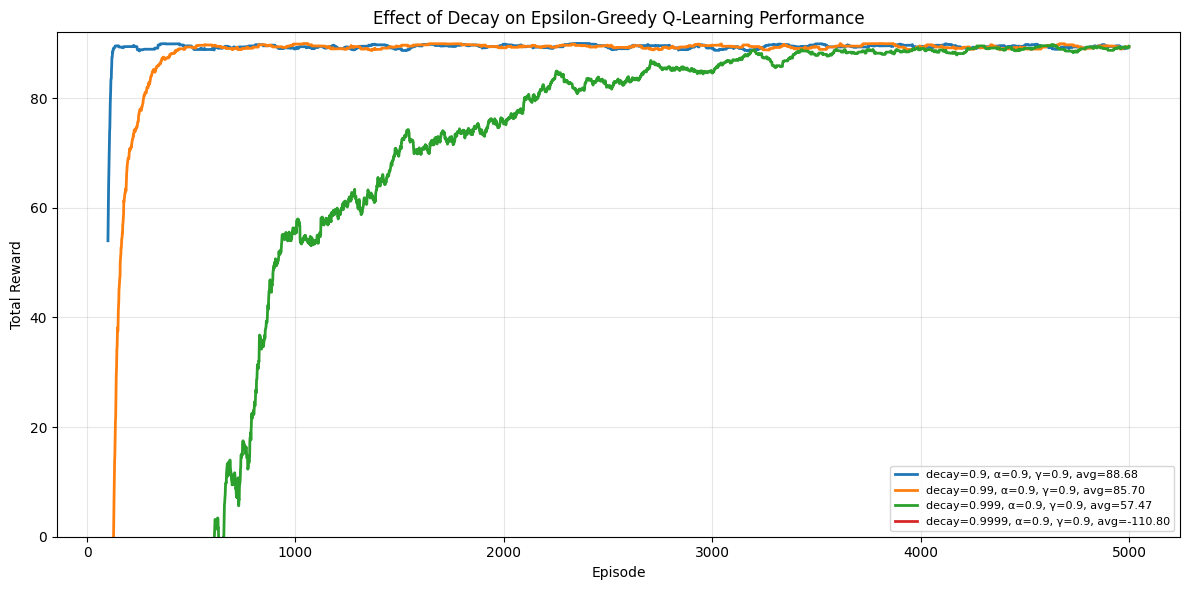

In [11]:
policy = "epsilon_greedy"
fixed_alpha = 0.9
fixed_gamma = 0.9
window = 100

decay_effect_df = summary_df[
    (summary_df["policy"] == policy) &
    (summary_df["alpha"] == fixed_alpha) &
    (summary_df["gamma"] == fixed_gamma)
].sort_values("decay")

plt.figure(figsize=(12, 6))

for row in decay_effect_df.itertuples():
    reward_list = results[row.key]["reward_list"]
    moving_average = pd.Series(reward_list).rolling(window=window).mean()
    episodes_range = range(1, len(reward_list) + 1)

    label = f"decay={row.decay}, α={row.alpha}, γ={row.gamma}, avg={row.avg_reward:.2f}"
    plt.plot(episodes_range, moving_average, linewidth=2, label=label)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Effect of Decay on Epsilon-Greedy Q-Learning Performance")
plt.legend(loc="best", fontsize=8, frameon=True)
plt.grid(True, alpha=0.3)
plt.ylim(0, 92)
plt.tight_layout()
plt.savefig("decay_effect_reward_curve.png", dpi=300, bbox_inches="tight")
plt.show()

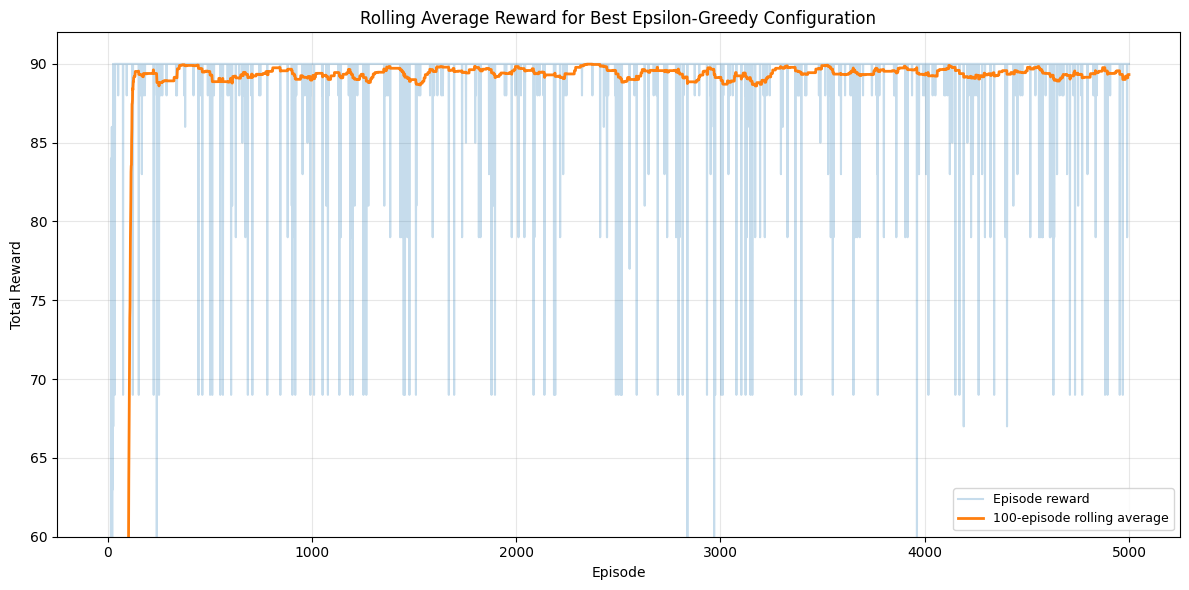

In [12]:
best_epsilon_row = summary_df[
    summary_df["policy"] == "epsilon_greedy"
].sort_values("avg_reward", ascending=False).iloc[0]

reward_list = results[best_epsilon_row["key"]]["reward_list"]
moving_average = pd.Series(reward_list).rolling(window=100).mean()
episodes_range = range(1, len(reward_list) + 1)

plt.figure(figsize=(12, 6))
plt.plot(episodes_range, reward_list, alpha=0.25, label="Episode reward")
plt.plot(episodes_range, moving_average, linewidth=2, label="100-episode rolling average")

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Rolling Average Reward for Best Epsilon-Greedy Configuration")
plt.legend(loc="best", fontsize=9, frameon=True)
plt.grid(True, alpha=0.3)
plt.ylim(60, 92)
plt.tight_layout()
plt.savefig("best_epsilon_rolling_reward.png", dpi=300, bbox_inches="tight")
plt.show()

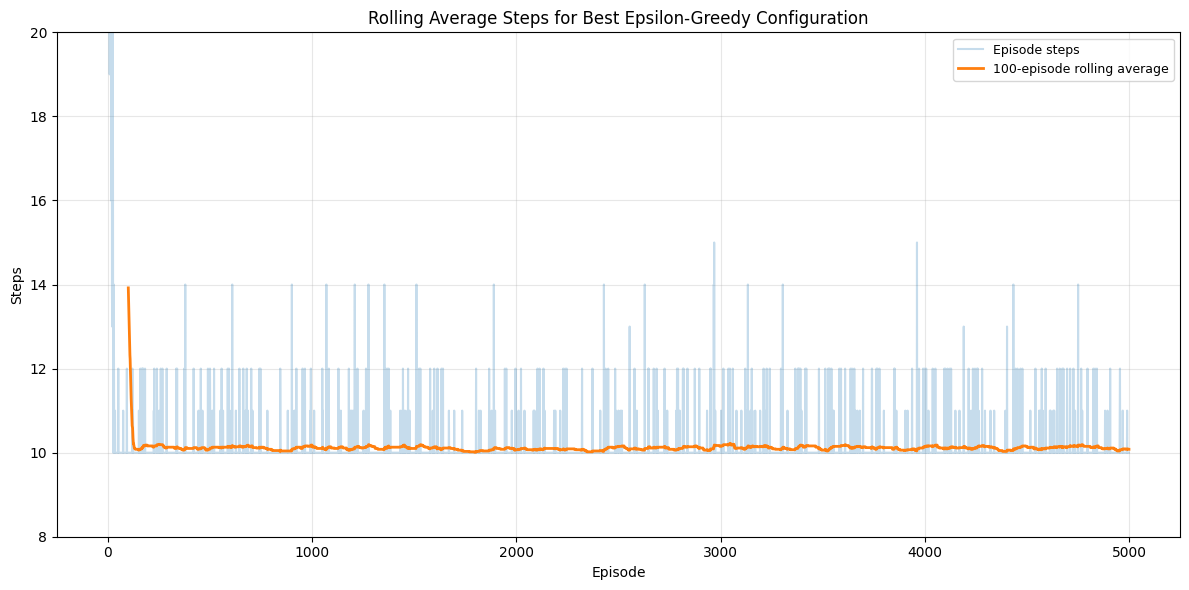

In [13]:
step_list = results[best_epsilon_row["key"]]["step_list"]
moving_average_steps = pd.Series(step_list).rolling(window=100).mean()
episodes_range = range(1, len(step_list) + 1)

plt.figure(figsize=(12, 6))
plt.plot(episodes_range, step_list, alpha=0.25, label="Episode steps")
plt.plot(episodes_range, moving_average_steps, linewidth=2, label="100-episode rolling average")

plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Rolling Average Steps for Best Epsilon-Greedy Configuration")
plt.legend(loc="best", fontsize=9, frameon=True)
plt.grid(True, alpha=0.3)
plt.ylim(8, 20)
plt.tight_layout()
plt.savefig("best_epsilon_rolling_steps.png", dpi=300, bbox_inches="tight")
plt.show()

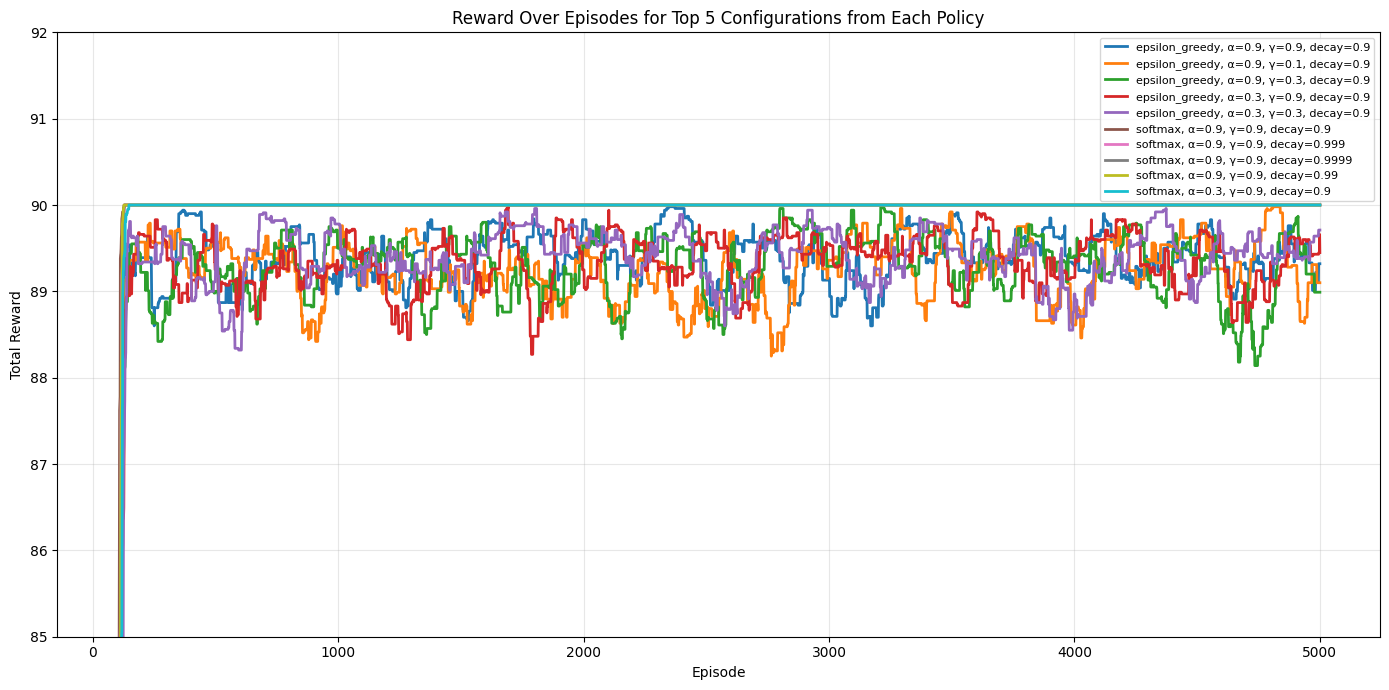

In [15]:
window = 100

plt.figure(figsize=(14, 7))

for row in top5_each_policy.itertuples():
    reward_list = results[row.key]["reward_list"]
    moving_average = pd.Series(reward_list).rolling(window=window).mean()
    episodes_range = range(1, len(reward_list) + 1)

    label = f"{row.policy}, α={row.alpha}, γ={row.gamma}, decay={row.decay}"
    plt.plot(episodes_range, moving_average, linewidth=2, label=label)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Over Episodes for Top 5 Configurations from Each Policy")
plt.legend(loc="best", fontsize=8, frameon=True)
plt.grid(True, alpha=0.3)
plt.ylim(85, 92)
plt.tight_layout()
plt.savefig("top5_each_policy_reward_over_episodes.png", dpi=300, bbox_inches="tight")
plt.show()

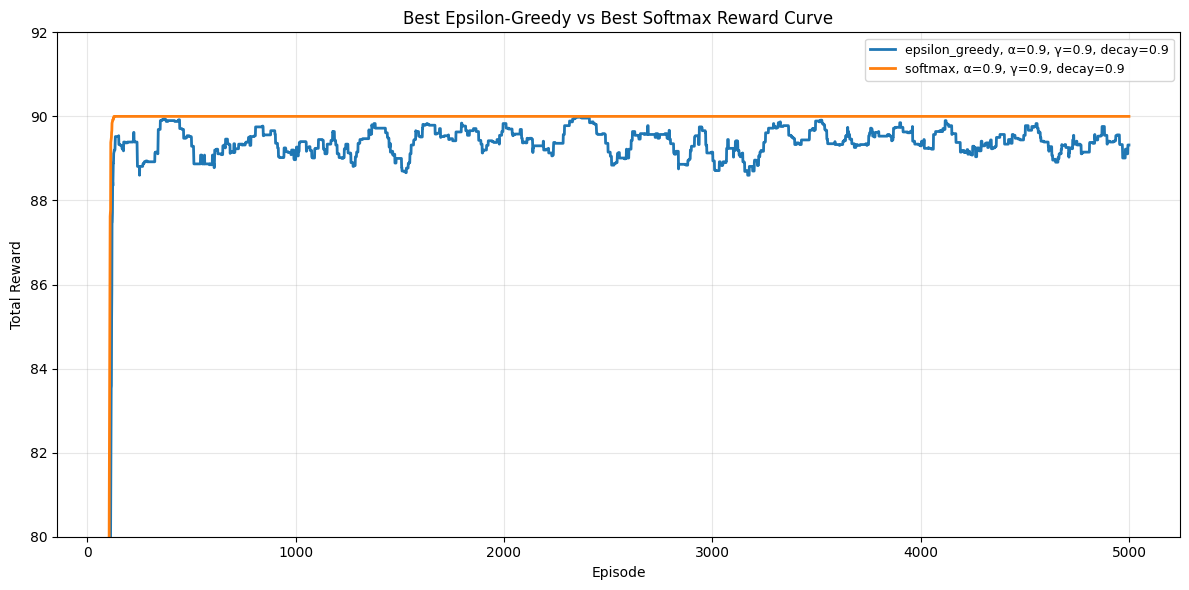

In [16]:
best_epsilon_row = summary_df[
    summary_df["policy"] == "epsilon_greedy"
].sort_values("avg_reward", ascending=False).iloc[0]

best_softmax_row = summary_df[
    summary_df["policy"] == "softmax"
].sort_values("avg_reward", ascending=False).iloc[0]

best_models_df = pd.DataFrame([best_epsilon_row, best_softmax_row])

window = 100

plt.figure(figsize=(12, 6))

for row in best_models_df.itertuples():
    reward_list = results[row.key]["reward_list"]
    moving_average = pd.Series(reward_list).rolling(window=window).mean()
    episodes_range = range(1, len(reward_list) + 1)

    label = f"{row.policy}, α={row.alpha}, γ={row.gamma}, decay={row.decay}"
    plt.plot(episodes_range, moving_average, linewidth=2, label=label)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Best Epsilon-Greedy vs Best Softmax Reward Curve")
plt.legend(loc="best", fontsize=9, frameon=True)
plt.grid(True, alpha=0.3)
plt.ylim(80, 92)
plt.tight_layout()
plt.savefig("best_epsilon_vs_best_softmax_reward.png", dpi=300, bbox_inches="tight")
plt.show()